# Brain Slice Geometric Reorienter
Give it one brain slice image + axis label → it finds the best rotation to match the atlas.

In [72]:
# import subprocess, sys
# subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--upgrade", "--force-reinstall",
#                        "numpy==2.0.2",
#                        "Pillow", "scipy", "matplotlib", "scikit-image", "scikit-learn",
#                        "SimpleITK", "tifffile", "czifile"])
# print("Done.")

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import tifffile
print("Imports OK.")

Imports OK.


In [74]:
FOLDER = Path("/kaggle/input/datasets/fatimanauman/standardmouse/standardmouse")
SAMPLES_PER_AXIS = 3

Found existing atlas.
Atlas volume shape (x, y, z): (528, 320, 456)


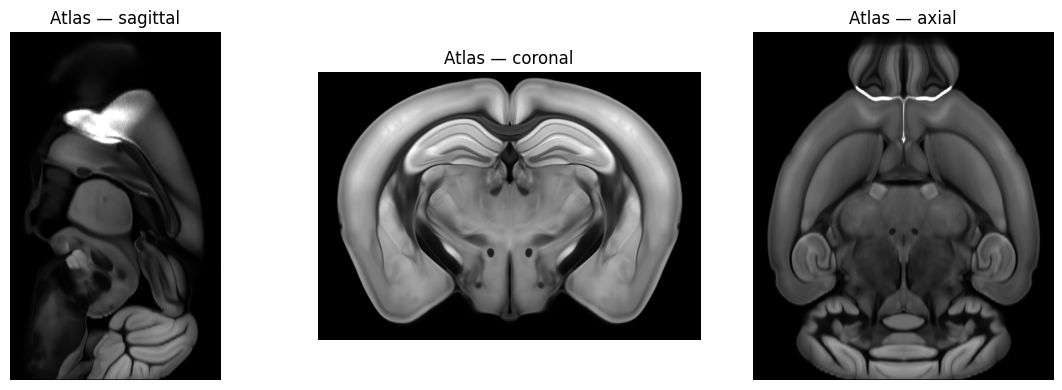

In [75]:
import SimpleITK as sitk
import urllib.request

ATLAS_PATH = Path("/kaggle/input/datasets/fatimanauman/atlastemplate/average_template_25.nrrd")

if not ATLAS_PATH.exists():
    print("Downloading Allen Mouse Atlas (~500MB)...")
    urllib.request.urlretrieve(
        "https://download.alleninstitute.org/informatics-archive/"
        "current-release/mouse_ccf/average_template/"
        "average_template_25.nrrd",
        ATLAS_PATH
    )
    print("Done.")
else:
    print("Found existing atlas.")

atlas_sitk = sitk.ReadImage(str(ATLAS_PATH))
orienter = sitk.DICOMOrientImageFilter()
orienter.SetDesiredCoordinateOrientation("RAS")
atlas_sitk = orienter.Execute(atlas_sitk)

atlas_sitk = sitk.PermuteAxes(atlas_sitk, [2, 1, 0])

atlas_vol = sitk.GetArrayFromImage(atlas_sitk).astype(np.float32)
print(f"Atlas volume shape (x, y, z): {atlas_vol.shape}")

AXIS_DIM = {"sagittal": 2, "coronal": 0, "axial": 1}

# Coronal: brain is wider than tall → horizontal axis → 90°
# Sagittal: brain is longer than tall → horizontal axis → 90°
# Axial: brain is wider than tall, roughly symmetric → 90°
# These are reference angles for PCA alignment.
AXIS_TARGET_ANGLE = {
    "coronal":   90.0,
    "sagittal":  90.0,
    "axial":     90.0,
}

# Expected aspect ratios (width/height) for each plane in standard orientation
AXIS_ASPECT = {
    "coronal":  1.3,
    "sagittal": 1.5,
    "axial":    1.2,
}

AXIS_SLICE_FRAC = {"coronal": 0.45, "axial": 0.5, "sagittal": 0.5}

def normalize(arr):
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)

fig, axes_preview = plt.subplots(1, 3, figsize=(12, 4))
for i, (axis, dim) in enumerate(AXIS_DIM.items()):
    mid = int(atlas_vol.shape[dim] * AXIS_SLICE_FRAC[axis])
    if   dim == 0: sl = atlas_vol[mid, :, :]
    elif dim == 1: sl = atlas_vol[:, mid, :]
    else:          sl = atlas_vol[:, :, mid]
    sl = normalize(sl)
    axes_preview[i].imshow(sl, cmap="gray", origin="lower")
    axes_preview[i].set_title(f"Atlas — {axis}")
    axes_preview[i].axis("off")
plt.tight_layout()
plt.show()

In [76]:
import random
from scipy.optimize import linear_sum_assignment
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects
from skimage.measure import perimeter
from sklearn.decomposition import PCA

SUPPORTED = {".png", ".jpg", ".jpeg", ".jfif", ".bmp", ".tif", ".tiff", ".czi"}

def load_slice(path):
    path = Path(path)
    ext = path.suffix.lower()
    if ext in (".png", ".jpg", ".jpeg", ".jfif", ".bmp"):
        img = Image.open(path).convert("L")
        return np.array(img, dtype=np.float32)
    elif ext in (".tif", ".tiff"):
        arr = tifffile.imread(str(path)).astype(np.float32)
        if arr.ndim == 3:
            if arr.shape[2] <= 4:
                arr = arr.mean(axis=2)
            else:
                arr = arr[arr.shape[0] // 2]
        return arr
    elif ext == ".czi":
        import czifile
        arr = czifile.imread(str(path)).squeeze().astype(np.float32)
        if arr.ndim == 3:
            if arr.shape[2] <= 4:
                arr = arr.mean(axis=2)
            else:
                arr = arr[arr.shape[0] // 2]
        return arr
    else:
        raise ValueError(f"Unsupported: {ext}")


def is_valid_slice(path):
    """
    Rejects:
    - Files that fail to load or aren't 2D after reduction
    - Images smaller than 64x64
    - Zero-variance (blank) images
    - Images with >50% near-black pixels (sparse MRI blobs)
    - Portrait images taller than wide by >20% (whole-body 3D renders)
    - Smooth-gradient images (3D surface renders lack histology texture)
    - Foreground that is a single compact blob (circularity > 0.85)
    """
    try:
        arr = load_slice(path)
        if arr.ndim != 2 or arr.shape[0] < 64 or arr.shape[1] < 64:
            return False
        if arr.std() < 1e-3:
            return False

        arr_norm = normalize(arr)

        # Reject dark-background renders: >50% near-black pixels
        if float((arr_norm < 0.05).mean()) > 0.50:
            return False

        # Reject portrait orientation: whole-body renders are tall and narrow
        h, w = arr.shape
        if h > w * 1.2:
            return False

        # Reject smooth 3D renders: histology has high local variance
        texture_ratio = float(arr_norm.std()) / (float(arr_norm.max() - arr_norm.min()) + 1e-8)
        if texture_ratio < 0.15:
            return False

        # Reject single compact blobs via circularity
        thresh = threshold_otsu(arr_norm)
        mask = arr_norm > thresh
        mask = remove_small_objects(mask, max_size=499)
        area = float(mask.sum())
        if area == 0:
            return False
        perim = float(perimeter(mask))
        if perim == 0:
            return False
        if (4 * np.pi * area) / (perim ** 2) > 0.85:
            return False

        return True
    except Exception:
        return False


def get_foreground_mask(img):
    """Otsu threshold on normalized image to isolate tissue from background."""
    img_norm = normalize(img)
    thresh = threshold_otsu(img_norm)
    mask = img_norm > thresh
    mask = remove_small_objects(mask, max_size=499)
    return mask


def principal_axes_angle(mask):
    """
    Returns the angle (degrees) of the principal axis of the foreground mask.
    Uses PCA on the pixel coordinates of foreground pixels.
    """
    coords = np.column_stack(np.where(mask))  # (N, 2): row, col
    if len(coords) < 50:
        return 0.0
    pca = PCA(n_components=2)
    pca.fit(coords)
    # Principal axis vector (eigenvector with largest eigenvalue)
    vec = pca.components_[0]
    angle_rad = np.arctan2(vec[0], vec[1])
    angle_deg = np.degrees(angle_rad)
    return angle_deg


def best_rotation(brain_slice, target_angle):
    """
    Rotates brain_slice in 90° increments so its principal axis
    best aligns with target_angle (the expected axis angle for this plane).
    Returns (reoriented_image, best_angle_applied, alignment_score).
    Alignment score is cos² of the residual angle — 1.0 is perfect.
    """
    mask = get_foreground_mask(brain_slice)
    brain_angle = principal_axes_angle(mask)

    best_score, best_k, best_img = -999, 0, brain_slice
    for k in range(4):
        candidate_angle = brain_angle + k * 90
        residual = (candidate_angle - target_angle + 180) % 360 - 180
        score = np.cos(np.radians(residual)) ** 2  # 1.0 when aligned, 0.0 when 90° off
        if score > best_score:
            best_score, best_k, best_img = score, k, np.rot90(brain_slice, k=k)

    return best_img, best_k * 90, float(best_score)


def resolve_flip(rotated_img, plane):
    """
    Checks if the PCA-rotated image needs a 180° flip.
    Uses foreground centroid position relative to image center.
    Coronal/axial: brain should have more mass in upper half (dorsal up).
    Sagittal: brain should have more mass in left half (rostral left).
    Returns (corrected_image, was_flipped).
    """
    mask = get_foreground_mask(rotated_img)
    coords = np.column_stack(np.where(mask))
    if len(coords) < 50:
        return rotated_img, False

    cy, cx = np.array(rotated_img.shape) / 2.0
    centroid_y, centroid_x = coords.mean(axis=0)

    if plane in ("coronal", "axial"):
        needs_flip = centroid_y > cy #if mass in lower half, flip
    else:
        needs_flip = centroid_x > cx

    if needs_flip:
        return np.rot90(rotated_img, k=2), True
    return rotated_img, False


atlas_slices = {}
for axis, dim in AXIS_DIM.items():
    mid = int(atlas_vol.shape[dim] * AXIS_SLICE_FRAC[axis])
    if   dim == 0: sl = atlas_vol[mid, :, :]
    elif dim == 1: sl = atlas_vol[:, mid, :]
    else:          sl = atlas_vol[:, :, mid]
    atlas_slices[axis] = normalize(sl)

found_axes = {}
for axis in ["coronal", "sagittal", "axial"]:
    candidates = [c for c in FOLDER.rglob(f"*{axis}*") if c.is_dir()]
    exact = [c for c in candidates if c.name.lower() == axis]
    pick = exact[0] if exact else (candidates[0] if candidates else None)
    if pick is not None:
        found_axes[axis] = pick

print("Found axes:", list(found_axes.keys()))
for axis, folder in found_axes.items():
    print(f"  {axis} -> {folder}")

axis_names = list(found_axes.keys())
atlas_axes = list(AXIS_DIM.keys())
score_matrix = np.full((len(axis_names), len(atlas_axes)), -999.0, dtype=float)


def aspect_score(mask, expected_ratio):
    """Score how close the foreground bounding box aspect ratio is to expected."""
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    h = rows.sum()
    w = cols.sum()
    if h == 0 or w == 0:
        return 0.0
    ratio = w / h
    return float(1.0 / (1.0 + abs(ratio - expected_ratio)))


for i, axis in enumerate(axis_names):
    folder = found_axes[axis]
    files = [f for f in folder.iterdir() if f.suffix.lower() in SUPPORTED and is_valid_slice(f)]
    if not files:
        continue
    sample_files = random.sample(files, min(3, len(files)))
    for j, atlas_axis in enumerate(atlas_axes):
        scores = []
        for sf in sample_files:
            sample = normalize(load_slice(sf))
            mask = get_foreground_mask(sample)
            scores.append(aspect_score(mask, AXIS_ASPECT[atlas_axis]))
        score_matrix[i, j] = float(np.mean(scores))

row_ind, col_ind = linear_sum_assignment(-score_matrix)
axis_to_atlas = {axis_names[r]: atlas_axes[c] for r, c in zip(row_ind, col_ind)}
print("Axis → Atlas mapping:")
for axis in axis_names:
    print(f"  {axis} -> {axis_to_atlas[axis]}")


samples = {}
for axis, folder in found_axes.items():
    files = [f for f in folder.iterdir() if f.suffix.lower() in SUPPORTED and is_valid_slice(f)]
    picked = random.sample(files, min(SAMPLES_PER_AXIS, len(files)))
    
    atlas_axis = axis_to_atlas.get(axis, axis)
    target_angle = AXIS_TARGET_ANGLE[atlas_axis]
    
    axis_samples = []
    for f in picked:
        brain = normalize(load_slice(f))
        reoriented, angle, score = best_rotation(brain, target_angle)
        reoriented, was_flipped = resolve_flip(reoriented, atlas_axis)
        if was_flipped:
            angle = (angle + 180) % 360
        axis_samples.append((brain, reoriented, angle, score, f.name))
    samples[axis] = axis_samples
    print(f"  {axis}: {len(axis_samples)} samples processed")

Found axes: ['coronal', 'sagittal', 'axial']
  coronal -> /kaggle/input/datasets/fatimanauman/standardmouse/standardmouse/coronal
  sagittal -> /kaggle/input/datasets/fatimanauman/standardmouse/standardmouse/sagittal
  axial -> /kaggle/input/datasets/fatimanauman/standardmouse/standardmouse/axial
Axis → Atlas mapping:
  coronal -> axial
  sagittal -> sagittal
  axial -> coronal
  coronal: 3 samples processed
  sagittal: 3 samples processed
  axial: 3 samples processed


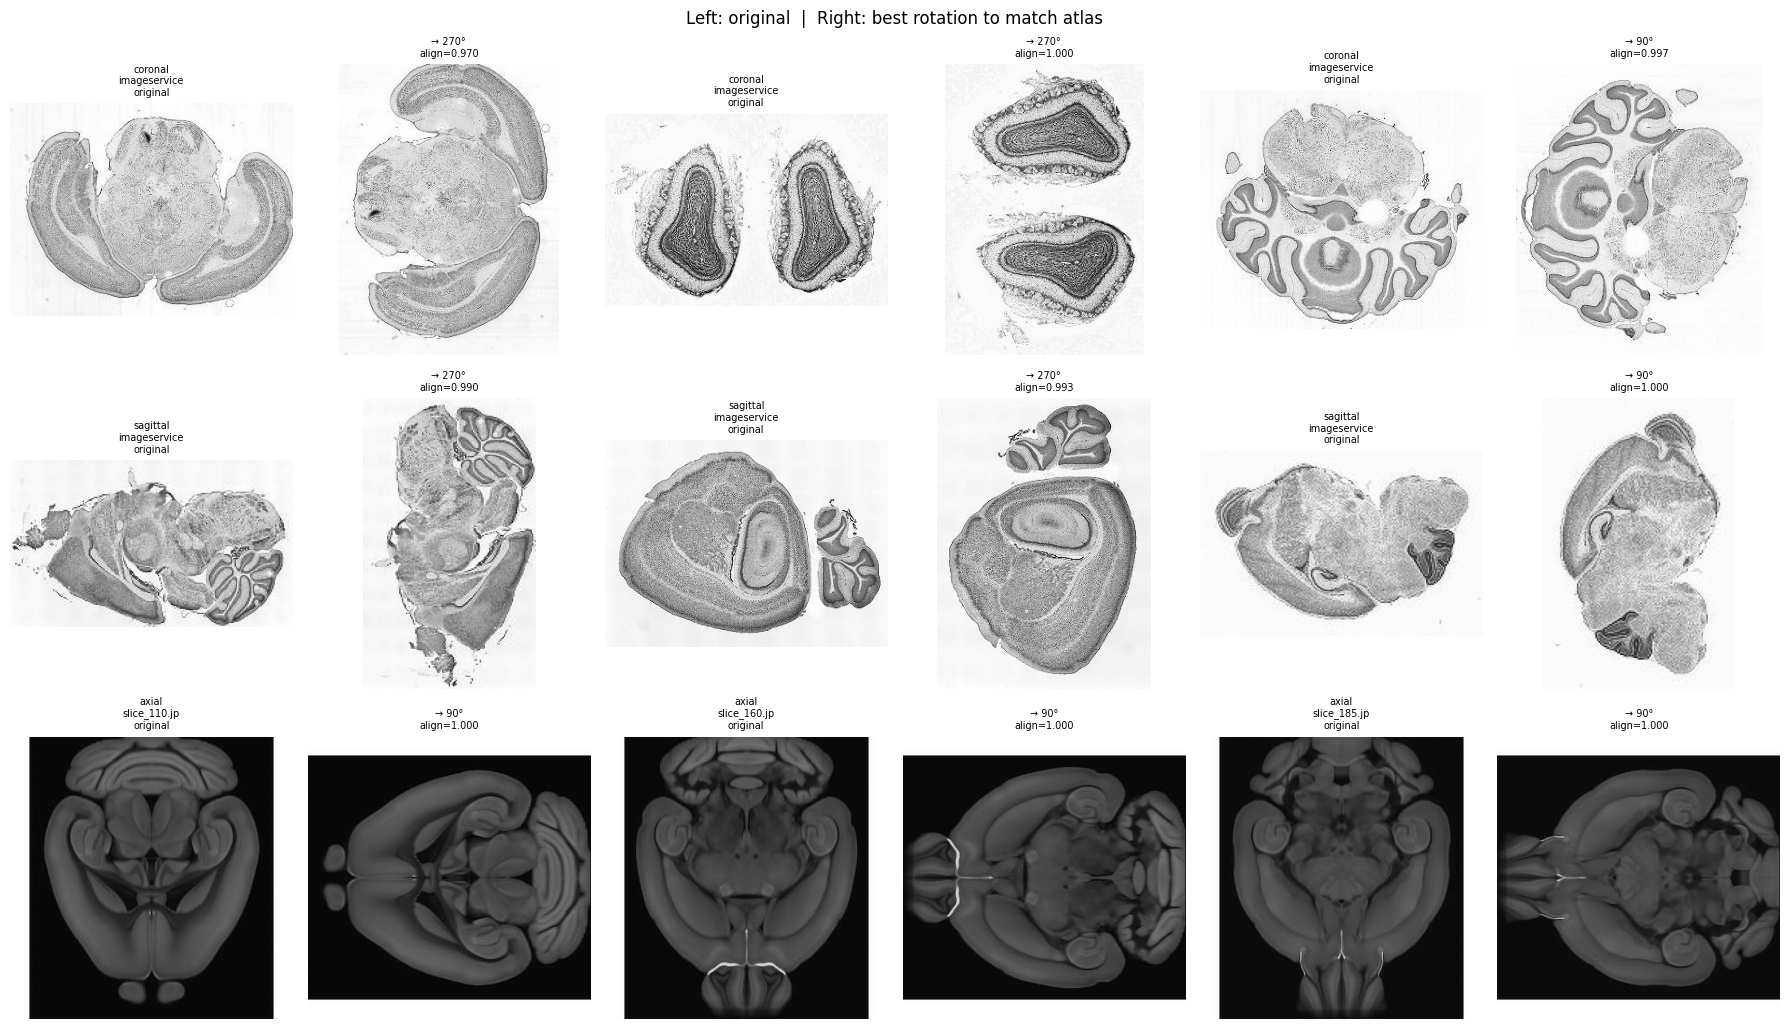

Saved to /kaggle/working/reorientation_grid.png


In [77]:
axes_list = list(samples.keys())
n_axes = len(axes_list)
n_cols = SAMPLES_PER_AXIS * 2

fig, grid = plt.subplots(n_axes, n_cols, figsize=(n_cols * 3, n_axes * 3.5))
if n_axes == 1: grid = grid[np.newaxis, :]

for row, axis in enumerate(axes_list):
    for col_pair, (original, reoriented, angle, score, fname) in enumerate(samples[axis]):
        c1 = col_pair * 2
        c2 = c1 + 1
        
        grid[row, c1].imshow(original, cmap="gray", origin="lower")
        grid[row, c1].set_title(f"{axis}\n{fname[:12]}\noriginal", fontsize=7)
        grid[row, c1].axis("off")
        
        grid[row, c2].imshow(reoriented, cmap="gray", origin="lower")
        grid[row, c2].set_title(f"→ {angle}°\nalign={score:.3f}", fontsize=7)
        grid[row, c2].axis("off")

plt.suptitle("Left: original  |  Right: best rotation to match atlas", fontsize=12)
plt.tight_layout()
plt.savefig("/kaggle/working/reorientation_grid.png", dpi=120)
plt.show()
print("Saved to /kaggle/working/reorientation_grid.png")